# Spam detection model comparison

Practical assignment for the **Machine Learning** course. This project addresses a
supervised spam email classification problem.

## Dataset

The project uses the [Email Spam Classification Dataset](https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv), available on Kaggle.

## Project Overview

### T1 - Problem Characterization and Spot-Checking

In the first stage, a Python pipeline loads and preprocesses the data, performs
exploratory data analysis, and quickly compares different supervised learning
algorithms. The results are evaluated using appropriate metrics, summarized, and
visualized to identify the most promising models.

The expected outputs are a reproducible Python pipeline, a technical report
describing the problem, methodology, and spot-checking results, and a selection of
2-3 algorithms for further investigation.

### T2 - In-Depth Evaluation

In the second stage, the selected models will be improved through hyperparameter
optimization, more robust evaluation, and statistical analysis. The best model will
also be interpreted to understand its quantitative results and extract insights
about email classification.

The final outputs will be an updated pipeline, a complete report, and an oral
presentation of the project.

# 1. Data downloading

In [52]:
%pip install -q kagglehub xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv", output_dir="data")

print("Path to dataset files:", path)

Path to dataset files: data


In [54]:
from pathlib import Path
import pandas as pd

data_path = Path("src/data/emails.csv")
if not data_path.exists():
    data_path = Path("data/emails.csv")
df = pd.read_csv(data_path)

print(df)


       Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  \
0        Email 1    0   0    1    0    0   0    2    0    0  ...         0   
1        Email 2    8  13   24    6    6   2  102    1   27  ...         0   
2        Email 3    0   0    1    0    0   0    8    0    0  ...         0   
3        Email 4    0   5   22    0    5   1   51    2   10  ...         0   
4        Email 5    7   6   17    1    5   2   57    0    9  ...         0   
...          ...  ...  ..  ...  ...  ...  ..  ...  ...  ...  ...       ...   
5167  Email 5168    2   2    2    3    0   0   32    0    0  ...         0   
5168  Email 5169   35  27   11    2    6   5  151    4    3  ...         0   
5169  Email 5170    0   0    1    1    0   0   11    0    0  ...         0   
5170  Email 5171    2   7    1    0    2   1   28    2    0  ...         0   
5171  Email 5172   22  24    5    1    6   5  148    8    2  ...         0   

      jay  valued  lay  infrastructure  military  allowing  ff 

## 1.1 Data summary

Shows data summary, class distribution and total sum of each word (features)

In [55]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}\n")

print("Data types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isna().sum().sum())

#print("\nClass distribution:")
#print(df["Prediction"].value_counts())
#print(df["Prediction"].value_counts(normalize=True).mul(100).round(2))

Rows: 5172
Columns: 3002

Data types:
int64    3001
str         1
Name: count, dtype: int64

Missing values:
0


In [56]:
import matplotlib.pyplot as plt

def plot_class_distribution(data: pd.DataFrame | pd.Series, target: str, classes: list,
                            title: str = "Class distribution"):
  labels_data = data if isinstance(data, pd.Series) else data[target]
  class_counts = labels_data.value_counts().sort_index()
  class_labels = {0: classes[0], 1: classes[1]}
  labels = [class_labels.get(value, str(value)) for value in class_counts.index]

  fig, ax = plt.subplots(figsize=(7, 5))
  bars = ax.bar(labels, class_counts.values, color=["#4C78A8", "#F58518"])
  ax.set_title(title)
  ax.set_xlabel("Class")
  ax.set_ylabel("Quantity")
  ax.bar_label(bars, labels=[f"{count} ({count / class_counts.sum():.1%})" for count in class_counts])
  ax.set_ylim(0, class_counts.max() * 1.15)
  plt.tight_layout()
  plt.show()

def plot_feature_frequency(df: pd.DataFrame, features: list[str], n: int):
  if not isinstance(n, int) or n == 0:
    raise ValueError("n must be an integer different from zero")
  if isinstance(features, str) or len(features) == 0:
    raise ValueError("features must contain at least one column name")

  missing_features = [feature for feature in features if feature not in df.columns]
  if missing_features:
    raise ValueError(f"Features not found in df: {missing_features}")

  feature_counts = df.loc[:, list(features)].sum().sort_values(ascending=False)
  non_zero_counts = feature_counts[feature_counts > 0]
  selected = (
    non_zero_counts.nlargest(n) if n > 0
    else non_zero_counts.nsmallest(abs(n))
  ).sort_values(ascending=True)

  fig_height = max(5, len(selected) * 0.32)
  fig, ax = plt.subplots(figsize=(10, fig_height))
  bars = ax.barh(selected.index, selected.values, color="#54A24B")
  ranking = "most frequent" if n > 0 else "least frequent"
  ax.set_title(f"{abs(n)} {ranking} features")
  ax.set_xlabel("Total number of occurrences")
  ax.set_ylabel("Feature")
  ax.bar_label(bars, padding=3)
  ax.set_xlim(0, selected.max() * 1.12)
  plt.tight_layout()
  plt.show()
  return selected

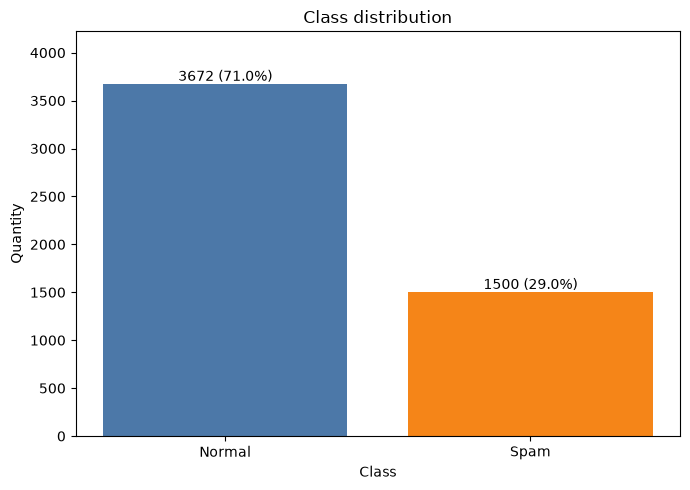

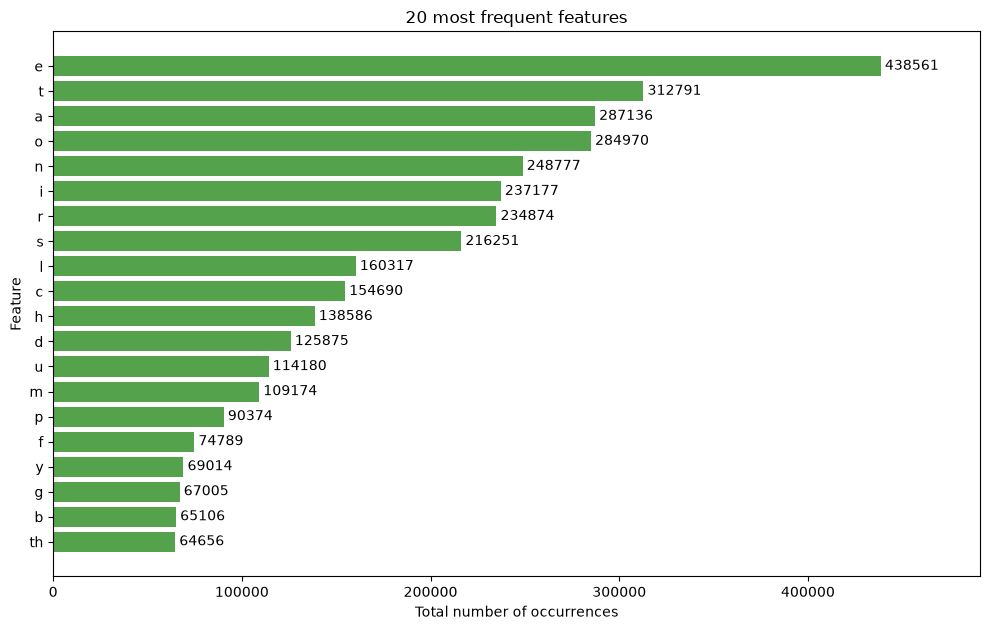

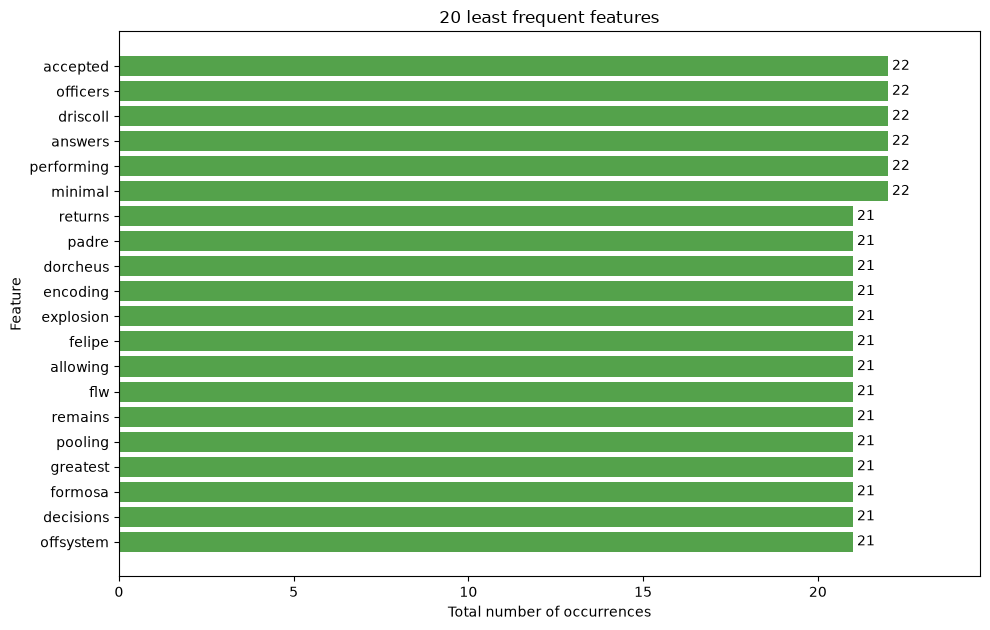

In [57]:
TARGET = "Prediction"
IDENTIFIER = "Email No."
FEATURES = [column for column in df.columns if column not in [IDENTIFIER, TARGET]]

plot_class_distribution(df, TARGET, ['Normal', 'Spam'])

top_n = [20, -20]

for n in top_n:
  plot_feature_frequency(df, FEATURES, n);

## 1.2 Data preparation and processing

Remove features that are not useful for prediction and apply TF-IDF normalization. The stratified train/test split and cross-validation folds preserve the class proportions without creating a separate validation set.


### TF-IDF normalization

Term Frequency-Inverse Document Frequency (TF-IDF) combines the frequency of a word in an email with its inverse document frequency across emails. Words found in many emails receive less weight, while words that are more distinctive retain more weight. With `sublinear_tf=True`, repeated counts are also scaled logarithmically; L2 normalization makes document vectors comparable.

The existing feature matrix contains numeric word counts and is mostly zero, so TF-IDF can weight the observed terms while keeping the representation sparse. We use `TfidfTransformer` because the CSV already supplies word counts. `TfidfVectorizer` would be appropriate for raw email text, which would first need tokenization and counting.

In each cross-validation fold, IDF is learned only from the internal training data and then applied to the internal validation data. The final transformer is fitted on all of `X_train` and used to transform `X_test`, which never contributes to the IDF calculation.


In [58]:
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

X = df.drop(columns=["Email No.", "Prediction"])
y = df["Prediction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

preprocessing = Pipeline([
    ("tfidf", TfidfTransformer(
        norm="l2",
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=True
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_partitions = []
fold_data = []
for fold_number, (train_indices, validation_indices) in enumerate(
    cv.split(X_train, y_train), start=1
):
    X_fold_train = X_train.iloc[train_indices]
    X_fold_validation = X_train.iloc[validation_indices]
    y_fold_train = y_train.iloc[train_indices]
    y_fold_validation = y_train.iloc[validation_indices]

    fold_preprocessing = clone(preprocessing)
    X_fold_train_tfidf = fold_preprocessing.fit_transform(X_fold_train)
    X_fold_validation_tfidf = fold_preprocessing.transform(X_fold_validation)

    fold_data.append({
        "fold": fold_number,
        "X_train": X_fold_train_tfidf,
        "X_validation": X_fold_validation_tfidf,
        "y_train": y_fold_train,
        "y_validation": y_fold_validation,
    })

    fold_partitions.append({
        "fold": fold_number,
        "train_rows": len(y_fold_train),
        "validation_rows": len(y_fold_validation),
        "train_matrix_shape": X_fold_train_tfidf.shape,
        "validation_matrix_shape": X_fold_validation_tfidf.shape,
    })

print(f"Train rows: {len(y_train)}; test rows: {len(y_test)}")
print(pd.DataFrame(fold_partitions).to_string(index=False))

# Fit the final preprocessing pipeline only on the full training set.
X_train_tfidf = preprocessing.fit_transform(X_train)
X_test_tfidf = preprocessing.transform(X_test)
print(f"Final TF-IDF matrices: train={X_train_tfidf.shape}, test={X_test_tfidf.shape}")


Train rows: 4137; test rows: 1035
 fold  train_rows  validation_rows train_matrix_shape validation_matrix_shape
    1        3309              828       (3309, 3000)             (828, 3000)
    2        3309              828       (3309, 3000)             (828, 3000)
    3        3310              827       (3310, 3000)             (827, 3000)
    4        3310              827       (3310, 3000)             (827, 3000)
    5        3310              827       (3310, 3000)             (827, 3000)
Final TF-IDF matrices: train=(4137, 3000), test=(1035, 3000)


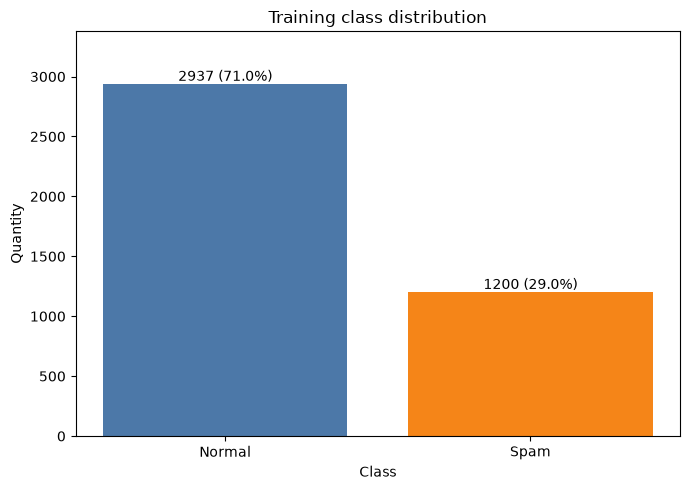

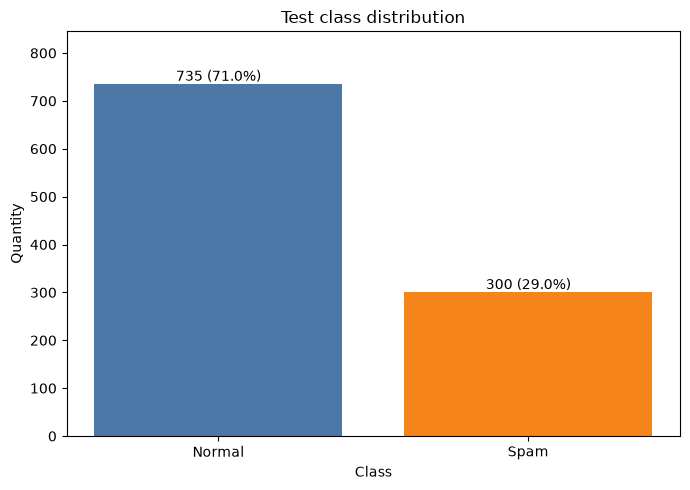

In [59]:
plot_class_distribution(y_train, TARGET, ['Normal', 'Spam'],
                        title="Training class distribution")
plot_class_distribution(y_test, TARGET, ['Normal', 'Spam'],
                        title="Test class distribution")


## 2. Definition of the approach, algorithms, and evaluation strategy

The goal is to classify each email as normal (`0`) or spam (`1`), making this a supervised binary classification task. The initial comparison includes Logistic Regression (a probabilistic linear model), Linear SVM (margin-based classification), Decision Tree (nonlinear rules), and XGBoost (a sequential ensemble of trees). A neural network will be added later to complete the five algorithms required for the assignment.

Accuracy, the proportion of correct predictions, is the primary comparison metric. Because spam is the minority class, F1-score, precision, and recall for class `1` are also reported. Each algorithm uses its standard training objective; this stage includes neither hyperparameter search nor decision-threshold tuning.

The held-out test set is excluded from spot-checking. All algorithms are evaluated on the same five stratified folds of `X_train` and `y_train`. Within each fold, TF-IDF is fitted only on the internal training data and then applied to the internal validation data to prevent information leakage.


In [60]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def calculate_accuracy(y_true, y_pred):
    """Return the proportion of correctly classified emails."""
    return accuracy_score(y_true, y_pred)


def calculate_f1_score(y_true, y_pred):
    """Return the F1-score for spam (class 1)."""
    return f1_score(y_true, y_pred, pos_label=1, zero_division=0)


def calculate_precision(y_true, y_pred):
    """Return precision for spam (class 1)."""
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)


def calculate_recall(y_true, y_pred):
    """Return recall for spam (class 1)."""
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)


## 3. Algorithm spot-checking

Each model is trained and evaluated once in each of the five folds, always using the same partitions. Predictions and all four metrics are recorded for every model and fold. The summary reports the mean and standard deviation; models are ranked by mean accuracy, with mean F1-score breaking ties. The ranking remains provisional until the neural network is evaluated.


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective="binary:logistic", tree_method="hist", random_state=42, n_jobs=1
    ),
}

fold_results = []
fold_predictions = {}
for model_name, model_template in models.items():
    for fold in fold_data:
        model = clone(model_template)
        model.fit(fold["X_train"], fold["y_train"])
        predictions = model.predict(fold["X_validation"])
        y_true = fold["y_validation"]

        fold_predictions[(model_name, fold["fold"])] = pd.DataFrame(
            {"y_true": y_true, "y_pred": predictions}, index=y_true.index
        )
        fold_results.append({
            "model": model_name,
            "fold": fold["fold"],
            "accuracy": calculate_accuracy(y_true, predictions),
            "f1_score": calculate_f1_score(y_true, predictions),
            "precision": calculate_precision(y_true, predictions),
            "recall": calculate_recall(y_true, predictions),
        })

results_by_fold = pd.DataFrame(fold_results)
display(results_by_fold.round(4))


,model,fold,accuracy,f1_score,precision,recall
0,Logistic Regression,1,0.9734,0.9542,0.9542,0.9542
1,Logistic Regression,2,0.9843,0.9730,0.9710,0.9750
2,Logistic Regression,3,0.9794,0.9649,0.9551,0.9750
3,Logistic Regression,4,0.9831,0.9703,0.9871,0.9542
4,Logistic Regression,5,0.9758,0.9582,0.9622,0.9542
5,Linear SVM,1,0.9831,0.9708,0.9708,0.9708
6,Linear SVM,2,0.9915,0.9855,0.9794,0.9917
7,Linear SVM,3,0.9843,0.9732,0.9633,0.9833
8,Linear SVM,4,0.9903,0.9833,0.9833,0.9833
9,Linear SVM,5,0.9843,0.9730,0.9710,0.9750


Provisional ranking of the four models (mean and standard deviation across five folds):


,accuracy_mean,accuracy_std,f1_score_mean,f1_score_std,precision_mean,precision_std,recall_mean,recall_std
model,,,,,,,,
Linear SVM,0.9867,0.0039,0.9772,0.0067,0.9736,0.0079,0.9808,0.0081
Logistic Regression,0.9792,0.0046,0.9641,0.0079,0.9659,0.0136,0.9625,0.0114
XGBoost,0.9662,0.0071,0.9425,0.0119,0.9289,0.0138,0.9567,0.0137
Decision Tree,0.9081,0.0056,0.8402,0.0102,0.8480,0.0074,0.8325,0.0130


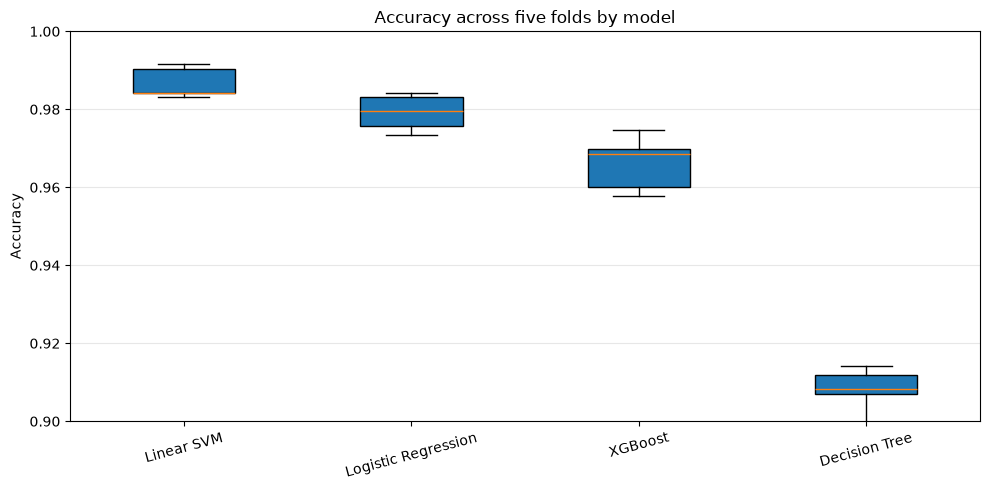

In [62]:
metric_columns = ["accuracy", "f1_score", "precision", "recall"]
spot_check_summary = results_by_fold.groupby("model", sort=False)[metric_columns].agg(
    ["mean", "std"]
)
spot_check_summary.columns = [
    f"{metric}_{statistic}" for metric, statistic in spot_check_summary.columns
]
spot_check_summary = spot_check_summary.sort_values(
    ["accuracy_mean", "f1_score_mean"], ascending=False
)

print("Provisional ranking of the four models (mean and standard deviation across five folds):")
display(spot_check_summary.round(4))

ranked_models = spot_check_summary.index.tolist()
accuracy_by_model = [
    results_by_fold.loc[results_by_fold["model"] == name, "accuracy"]
    for name in ranked_models
]
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(accuracy_by_model, patch_artist=True)
ax.set_xticks(range(1, len(ranked_models) + 1), ranked_models, rotation=15)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy across five folds by model")
ax.set_ylim(0.9, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Final evaluation on the test set

After spot-checking, each of the four algorithms is fitted again on all of `X_train_tfidf` and evaluated once on `X_test_tfidf`. TF-IDF has been fitted only on `X_train`; the `y_test` labels are used solely to calculate metrics. No parameter or decision threshold is changed based on test results. The neural network can later be evaluated using the same protocol.


In [63]:
final_models = {}
test_predictions = {}
test_rows = []
for model_name, model_template in models.items():
    final_model = clone(model_template)
    final_model.fit(X_train_tfidf, y_train)
    predictions = final_model.predict(X_test_tfidf)

    final_models[model_name] = final_model
    test_predictions[model_name] = pd.Series(
        predictions, index=y_test.index, name=model_name
    )
    test_rows.append({
        "model": model_name,
        "accuracy": calculate_accuracy(y_test, predictions),
        "f1_score": calculate_f1_score(y_test, predictions),
        "precision": calculate_precision(y_test, predictions),
        "recall": calculate_recall(y_test, predictions),
    })

test_results = pd.DataFrame(test_rows).sort_values(
    "accuracy", ascending=False
).reset_index(drop=True)
print("Evaluation on the test set (spam = 1):")
print(test_results.to_string(index=False, float_format=lambda value: f"{value:.4f}"))


Evaluation on the test set (spam = 1):
              model  accuracy  f1_score  precision  recall
         Linear SVM    0.9874    0.9784     0.9736  0.9833
Logistic Regression    0.9855    0.9752     0.9672  0.9833
            XGBoost    0.9710    0.9497     0.9561  0.9433
      Decision Tree    0.9072    0.8411     0.8355  0.8467
